
# From Variance Compression to Latent Structure

## PCA and Factor Analysis with the Ames Housing Dataset

### Learning objectives

By the end of this notebook, students should be able to:

- Explain the conceptual goal of Factor Analysis
- Distinguish PCA from FA
- Apply PCA and interpret explained variance
- Evaluate whether a dataset is suitable for FA
- Apply Exploratory Factor Analysis (EFA)
- Interpret factor loadings cautiously
- Understand factors as hypotheses about latent structure



# 1. What does Factor Analysis do?

Factor Analysis (FA) is a statistical technique used to investigate whether several observed variables may be partially explained by a smaller number of *latent dimensions* (called factors).

The core idea is:

> observed correlations may emerge because variables share underlying latent causes.

## Example

Suppose we observe the following housing variables:

- living area
- garage size
- number of rooms
- basement area
- construction quality

These variables may be correlated because they reflect broader latent dimensions such as:

- house size
- construction quality
- modernization

Importantly:

> factors are hypotheses about shared structure, not directly observed truths.

## Shared variance vs unique variance

FA assumes that each variable contains:

- shared/common variance
- unique variance
- noise/error

Conceptually:

$$
X = \Lambda F + \epsilon
$$

Where:

- $X$ = observed variables
- $F$ = latent factors
- $\Lambda$ = factor loadings
- $\epsilon$ = noise/error



# 2. Dataset and Variable Selection

We will use a curated subset of continuous variables from the Ames Housing dataset.

The objective is not to use *all available variables*, but rather to construct a coherent analytical block where latent structure may plausibly exist.

## Hypothesis

These variables may reflect latent dimensions such as:

- house size
- construction quality
- modernization
- functional capacity

Again:

> these are interpretive hypotheses, not factual discoveries.


In [31]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


from factor_analyzer.factor_analyzer import (
    calculate_kmo,
    calculate_bartlett_sphericity
)


from sklearn.decomposition import FactorAnalysis

from factor_analyzer.rotator import Rotator





## Load the dataset

Replace the path below with your local Ames Housing dataset file.


In [32]:

df = pd.read_csv("../01_Week1/data/raw/AmesHousing.csv")

df.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [33]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [34]:

factor_cols = [
    "Overall Qual",
    "Overall Cond",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area",
    "Garage Cars",
    "1st Flr SF",
    "TotRms AbvGrd",
    "Year Built"
]

#subset somente com as variaveis escolhidas
X = df[factor_cols].dropna()

X.head()


,Overall Qual,Overall Cond,Gr Liv Area,Total Bsmt SF,Garage Area,Garage Cars,1st Flr SF,TotRms AbvGrd,Year Built
0,6,5,1656,1080.0,528.0,2.0,1656,7,1960
1,5,6,896,882.0,730.0,1.0,896,5,1961
2,6,6,1329,1329.0,312.0,1.0,1329,6,1958
3,7,5,2110,2110.0,522.0,2.0,2110,8,1968
4,5,5,1629,928.0,482.0,2.0,928,6,1997


| Variável      | Representa                |
| ------------- | ------------------------- |
| Overall Qual  | qualidade geral           |
| Overall Cond  | condição geral            |
| Gr Liv Area   | área habitável            |
| Total Bsmt SF | tamanho do porão          |
| Garage Area   | tamanho da garagem        |
| Garage Cars   | capacidade da garagem     |
| 1st Flr SF    | tamanho do primeiro andar |
| TotRms AbvGrd | número de cômodos         |
| Year Built    | idade/modernidade         |

Todas estão relacionadas a:
- tamanho
- qualidade
- capacidade
- padrão construtivo



# 3. PCA vs Factor Analysis

PCA and FA may produce numerically similar low-dimensional structures, but they answer different questions.

| PCA | Factor Analysis |
|---|---|
| Dimensionality reduction | Latent structure modelling |
| Variance compression | Covariance explanation |
| Components are mathematical constructs | Factors are hypothetical latent variables |
| Uses total variance | Uses shared/common variance |
| Primarily geometric | Primarily interpretive |

## Key distinction

> PCA compresses variance.

> Factor Analysis models latent causes behind covariance.


PCA é mais:
- exploratório
- geométrico
- data-driven

FA é mais:
- teórico
- estatístico
- baseado em latent constructs


# 4. Data Preparation

PCA and FA are scale-sensitive methods.

Variables measured on larger scales can dominate the structure.

Therefore, we standardize the variables before analysis.


In [35]:

scaler = StandardScaler()

#normalizacao dos dados
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=factor_cols
)

X_scaled.head()


,Overall Qual,Overall Cond,Gr Liv Area,Total Bsmt SF,Garage Area,Garage Cars,1st Flr SF,TotRms AbvGrd,Year Built
0,-0.068035,-0.506128,0.309071,0.064275,0.256326,0.306303,1.266316,0.353570,-0.376451
1,-0.776958,0.393655,-1.194582,-0.385111,1.195786,-1.008735,-0.672920,-0.918239,-0.343375
2,-0.068035,0.393655,-0.337896,0.629413,-0.748246,-1.008735,0.431934,-0.282335,-0.442602
3,0.640888,-0.506128,1.207306,2.401993,0.228421,0.306303,2.424755,0.989474,-0.111845
4,-0.776958,-0.506128,0.255652,-0.280708,0.042389,0.306303,-0.591268,-0.282335,0.847350



# 5. Exploring Correlation Structure

Before PCA or FA, we inspect the correlation matrix.

Questions:

- Which variables cluster together?
- Which variables seem redundant?
- Is there evidence of shared structure?


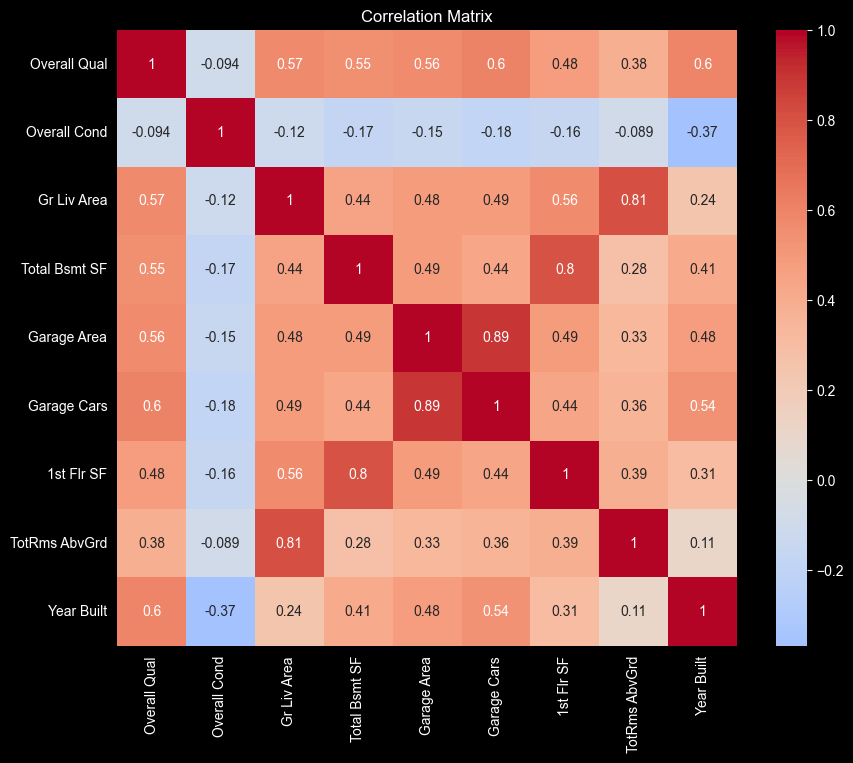

In [36]:

#primeiro entendedo a correlation
corr = X_scaled.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()



# 6. PCA — Variance Compression

PCA investigates whether most variance can be represented using fewer dimensions.

It does not assume latent causes.


In [37]:
#Fazendo o PCA para os dados normalizados
pca = PCA()

pca.fit(X_scaled)

explained = pca.explained_variance_ratio_

explained


array([0.49817841, 0.14631471, 0.10574336, 0.10234251, 0.06856681,
       0.03118243, 0.02109282, 0.01537037, 0.01120859])

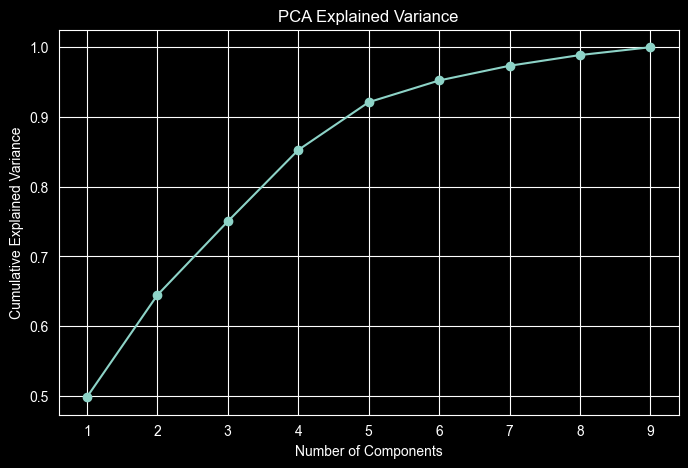

In [38]:

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained)+1),
    explained.cumsum(), #plot da soma cumulativa da lista explained
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)
plt.show()



## Interpretation

Questions:

- How many components capture most variance?
- Is variance concentrated?
- Does dimensionality reduction seem plausible?

PCA suggests whether lower-dimensional structure may exist.



# 7. From PCA to Factor Analysis

PCA tells us that lower-dimensional structure may exist.

Factor Analysis asks:

> can this structure be interpreted as latent dimensions generating the observed correlations?



# 8. Evaluating Factor Analysis Adequacy

Before fitting a factor model, we evaluate whether the correlation structure is suitable for FA.



## Bartlett's Test

Bartlett’s test evaluates whether the correlation matrix differs significantly from an identity matrix.

If variables are nearly independent, FA is usually inappropriate.


In [39]:

chi_square, p_value = calculate_bartlett_sphericity(X_scaled)

print("Bartlett p-value:", p_value)

#testa a matriz de correlacao que fizemos acima e compara com a matriz identidade
# |1 0 0|
# |0 1 0|
# |0 0 1|


Bartlett p-value: 0.0



## KMO (Kaiser-Meyer-Olkin)

KMO evaluates whether variables share enough common variance to justify a factor model.

Rough guideline:

- > 0.80 → very good
- > 0.70 → acceptable
- < 0.50 → problematic


In [40]:

kmo_all, kmo_model = calculate_kmo(X_scaled)

print("KMO:", kmo_model)

# Queremos:
# - correlações simples altas
# - correlações parciais baixas


# É a correlação entre duas variáveis removendo o efeito das outras.
# Exemplo:
# - Gr Liv Area
# - Garage Area
# podem parecer correlacionadas.
#
# Mas talvez isso aconteça apenas porque ambas dependem de:
# - Overall Qual
# A correlação parcial tenta remover isso.

KMO: 0.7520942230122615



# 9. Choosing the Number of Factors

The number of factors is not purely automatic.

We combine:

- eigenvalues
- scree plot
- interpretability
- substantive reasoning


In [41]:
# Ajusta o modelo
fa = FactorAnalysis(rotation=None)

X_fa = fa.fit_transform(X_scaled)

# Eigenvalues aproximados
ev = np.var(X_fa, axis=0)

print(ev)

[0.8825757  0.55856424 0.41117471 0.22198668 0.07915665 0.
 0.         0.         0.        ]


In [42]:
corr = np.corrcoef(X_scaled, rowvar=False)

ev, v = np.linalg.eig(corr)

print(ev)

[4.48360568 1.31683239 0.61710127 0.95169027 0.92108257 0.28064186
 0.10087729 0.13833332 0.18983534]


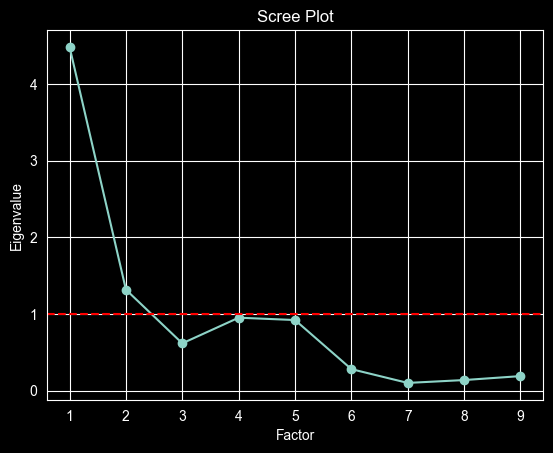

In [43]:


plt.plot(range(1, len(ev)+1), ev, marker='o')
plt.axhline(y=1, color='red', linestyle='--')

plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')

plt.show()


## Interpretation

Questions:

- Where is the elbow?
- How many factors seem defensible?
- Does interpretability matter?

Ambiguity is normal in Factor Analysis.



# 10. Running Factor Analysis

We now fit a two-factor solution using Varimax rotation.

Rotation improves interpretability.

It does not discover the “true” structure.


In [44]:


fa2 = FactorAnalysis(n_components=2)

fa2.fit(X_scaled)

loadings = pd.DataFrame(
    fa2.components_.T,
    columns=['Factor1', 'Factor2'],
    index=factor_cols
)

print(loadings.round(3))

               Factor1  Factor2
Overall Qual     0.622   -0.326
Overall Cond    -0.136    0.143
Gr Liv Area      0.983    0.129
Total Bsmt SF    0.493   -0.276
Garage Area      0.588   -0.724
Garage Cars      0.593   -0.733
1st Flr SF       0.597   -0.184
TotRms AbvGrd    0.795    0.188
Year Built       0.311   -0.482


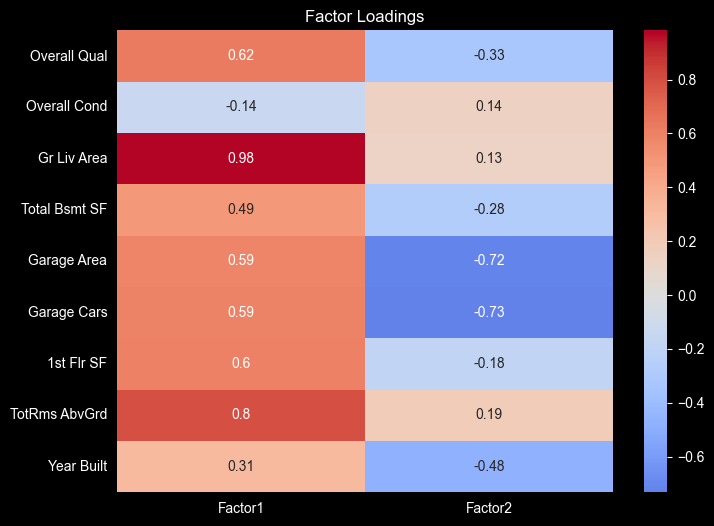

In [45]:

plt.figure(figsize=(8,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Factor Loadings")
plt.show()



# 11. Communalities

Communality estimates how much of each variable’s variance is explained by common latent structure.

Variables with low communalities may not fit the factor structure well.


In [46]:
import pandas as pd
import numpy as np

# loadings
loadings = fa.components_.T

# communalities
communalities = pd.DataFrame({
    "Communality": np.sum(loadings**2, axis=1)
}, index=factor_cols)

communalities.round(3)

,Communality
Overall Qual,0.598
Overall Cond,0.204
Gr Liv Area,0.700
Total Bsmt SF,0.626
Garage Area,0.697
Garage Cars,0.715
1st Flr SF,0.634
TotRms AbvGrd,0.588
Year Built,0.533



# 12. Comparing Rotations

We now compare Varimax (orthogonal) and Oblimin (correlated factors).

This comparison highlights an important conceptual point:

> rotation changes interpretation and assumptions.


In [47]:
# ======================
# Factor Analysis sklearn
# ======================

fa = FactorAnalysis(n_components=2)

fa.fit(X_scaled)

# loadings iniciais
loadings = fa.components_.T

# ======================
# Rotação Oblimin
# ======================

rotator = Rotator(method='oblimin')

loadings_oblimin = rotator.fit_transform(loadings)

# dataframe
loadings_oblimin_df = pd.DataFrame(
    loadings_oblimin,
    index=factor_cols,
    columns=['Factor1', 'Factor2']
)

print(loadings_oblimin_df.round(3))

               Factor1  Factor2
Overall Qual     0.315   -0.488
Overall Cond    -0.016    0.189
Gr Liv Area      0.975   -0.033
Total Bsmt SF    0.236   -0.407
Garage Area     -0.011   -0.938
Garage Cars     -0.012   -0.949
1st Flr SF       0.398   -0.320
TotRms AbvGrd    0.850    0.069
Year Built      -0.079   -0.610



# 13. Final Interpretation Exercise

Write a short interpretation paragraph discussing:

- What latent dimensions may be represented
- Which variables define each factor
- Why the interpretation is uncertain
- Why the factors should be treated as hypotheses rather than facts

## Important

Factor Analysis does not automatically discover real entities hidden in the data.

Factor models are:

- statistical simplifications
- interpretive constructions
- theory-dependent hypotheses



# 14. Conclusion

PCA and FA may produce similar low-dimensional structures,
but they express different claims about the world.

- PCA is fundamentally geometric.
- Factor Analysis is fundamentally interpretive.

The central idea of FA is:

> observed correlations may emerge because variables share latent causes plus noise.
